# Projeto Computacional de Mecânica Clássica

In [ ]:
import matplotlib.pyplot as plt
from math import exp
from __future__ import annotations
from utils.linear_algebra import Vec3, sum_vec3

## Conceito de uma particula

In [ ]:
class Particle:
    mass:float
    position: Vec3
    velocity: Vec3
    def __init__(self, mass: float, position: Vec3, velocity: Vec3) -> None:
        self.mass = mass
        self.position = position
        self.velocity = velocity
    def __repr__(self) -> str:
        return f"Particle(mass={self.mass}, position={self.position}, velocity={self.velocity})"
    
    def update_position(self, dt: float) -> None:
        self.position += self.velocity * dt
    def update_velocity(self, forces: list[Vec3], dt: float) -> None:
        total_force = sum_vec3(forces)
        acceleration = total_force / self.mass
        self.velocity += acceleration * dt

## Forças

### Força da gravidade 
#### $$\vec F_g = ma_g\cdot\hat k$$

In [9]:
def gravitational_force(particle: Particle, a:float) -> Vec3:
    magnitude = -particle.mass * a
    return Vec3(0, 0, magnitude)

### Força de arrasto
#### $$\begin{matrix}\beta_\uparrow(z) = \beta_0 e^{-z/ H} && \gamma_\uparrow(z) = \gamma_0 e^{-z/ H}\\\beta_\downarrow(z) = r_\beta\beta_\uparrow(z) && \gamma_\downarrow(z) = r_\gamma\gamma_\uparrow(z)\end{matrix}$$
#### $$\vec F_d =\begin{cases}- \beta_\uparrow(z)\vec v - \gamma_\uparrow(z)\|\vec v\|\vec v, & v_z > 0 \\- \beta_\downarrow(z)\vec v - \gamma_\downarrow(z)\|\vec v\|\vec v, & v_z < 0\end{cases}$$

In [ ]:
def drag_beta_up(particle: Particle, beta_o: float, h: float) -> float:
    return beta_o * exp(-particle.position.z / h)
def drag_gamma_up(particle: Particle, gamma_o: float, h: float) -> float:
    return gamma_o * exp(-particle.position.z / h)
def drag_force(particle: Particle, beta_o: float, gamma_o: float, r_beta: float, r_gamma: float, h:float) -> Vec3:
    speed = particle.velocity.length()

    if particle.velocity.z > 0:
        beta = drag_beta_up(particle, beta_o, h)
        gamma = drag_gamma_up(particle, gamma_o, h)
    else:
        beta = r_beta * drag_beta_up(particle, beta_o, h)
        gamma = r_gamma * drag_gamma_up(particle, gamma_o, h)

    # SEMPRE oposto à velocidade
    return particle.velocity * (-beta - gamma*speed)

## Simulação

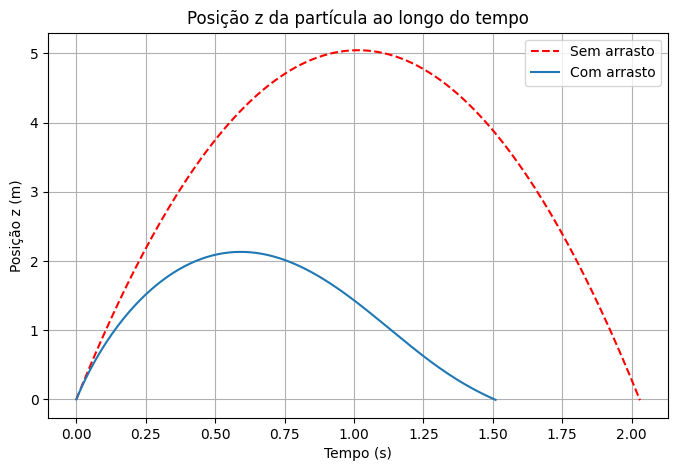

In [11]:
## Parâmetros de simulação
TIME_STEP = 0.01                    # [s]
## Força Gravitacional
GRAVITATIONAL_ACCELERATION = 9.81   # [m/s^2]
## Força de arrasto
BETA_O = 4.0                        #
GAMMA_O = 0.05                      #
R_BETA = 2.0                        #
R_GAMMA = 1.0                       #
H = 1.0                             # [m]


def simulate_until_ground(with_drag=True):
    particle = Particle(mass=1.0, position=Vec3(0.0, 0.0, 0.0), velocity=Vec3(0.0, 0.0, 10.0))
    z_positions = [particle.position.z]
    times = [0.0]
    t = 0.0
    while particle.position.z >= 0:
        if with_drag:
            forces = [
                gravitational_force(particle, a=GRAVITATIONAL_ACCELERATION),
                drag_force(particle, beta_o=BETA_O, gamma_o=GAMMA_O, r_beta=R_BETA, r_gamma=R_GAMMA, h=H)
            ]
        else:
            forces = [
                gravitational_force(particle, a=GRAVITATIONAL_ACCELERATION)
            ]
        particle.update_velocity(forces, TIME_STEP)
        particle.update_position(TIME_STEP)
        t += TIME_STEP
        z_positions.append(particle.position.z)
        times.append(t)
        if len(times) > 1000000:  # safety break for infinite loop
            break
    return times, z_positions

times_drag, z_drag = simulate_until_ground(with_drag=True)
times_no_drag, z_no_drag = simulate_until_ground(with_drag=False)

plt.figure(figsize=(8,5))
plt.plot(times_no_drag, z_no_drag, 'r--', label='Sem arrasto')
plt.plot(times_drag, z_drag, label='Com arrasto')
plt.xlabel('Tempo (s)')
plt.ylabel('Posição z (m)')
plt.title('Posição z da partícula ao longo do tempo')
plt.legend()
plt.grid(True)
plt.show()